# Bayesian Hierarchical NFL Season Simulator

## Thesis

Many game-theory and optimization workflows require a *stochastic* representation of a system's outcomes. *Stochastic* processes require a distribution of plausible outcomes, not a single predicted result. Here the system is an NFL regular season. We build (what I am calling) a **U-matrix**: a 2-D array of shape `(matchups × draws)` where each row is one of the 272 matchups that make up an NFL season, each column (draw) is one simulated season, and each cell is a win/loss outcome. Populating this array with win/loss outcomes requires a Monte Carlo simulation of each game and each season. One could build a model that would assign each matchup a probability of the home team winning, then stochastically generate a binary outcome subject to those probabilities. 

The central question is: **does our simulation reproduce the real-world distribution of team win totals?**

A naive **frequentist** approach treats each game's win probability as a fixed constant derived from a Machine Learning model trained on historical pre-season data. Simulating many seasons under these fixed probabilities produces a distribution of team win totals that is **too narrow** (too much probability mass centralized around 8 wins). Plotting historical win totals shows something different: a noticeably **flatter distribution**, with meaningful probability mass at extreme win totals (2-4 wins, 13-15 wins). This is due to teams routinely over- or under-performing relative to their pre-season expectations.

A team's actual in-season strength is not a point estimate, but a random variable. A **Bayesian hierarchical model** quantifies this: each team draws a season-level deviation `e_tk` from a shared prior. This captures the fact that over/under-performance is *correlated throughout the season* - a team that is running hot in Week 4 tends still to be running hot in Week 12.

Once we estimate the standard deviation of those season effects (`σ_e_tk`) from historical data, we can propagate that uncertainty through the simulation. The Bayesian U-matrix then produces a win distribution that **matches the historical plateau shape** demonstrating the power of Bayesian uncertainty quantification and its necessity for realistic Monte Carlo simulation.

As a natural by-product of this analysis, we also gain an emperical estimation of **league-wide** and **team-specific home feild advantage** as part of the modeling process. For the ML Engineer, this is a great practical explanation of how modifying the decision boundary in a classification problem with class imbalance can have real world significance and justification. For the reader who is also a fan of the NFL, this will be an interesting insight derived from publically avaiable data. 

## Workflow

1. **Data & Feature Engineering** - pre-season futures odds + pythagorean performance lags from prior season  
2. **Feature Selection** - L1 Lasso identifies polynomial candidate features; iterative L2 addition finds the curated set  
3. **Frequentist Simulation** - fixed win probabilities; the resulting histogram fails to match the historical distribution  
4. **Bayesian Hierarchical Model** - team-season random effects quantify within-season performance variance  
5. **Bayesian Simulation** - σ-draws propagate uncertainty; histogram matches the historical distribution  
6. **Single-Season U-Matrix** - full 272-game simulation of the 2021 NFL season for use in other projects in this repo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import f1_score, make_scorer, accuracy_score
from scipy.special import expit
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score

import sys; sys.path.append('..')
from utils import build_game_df, team_convert  # custom utility module
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

%matplotlib inline
np.random.seed(42)

c:\Users\ASR10\anaconda3\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Section 2 - Data Loading & Preprocessing

In [2]:
# Load SQL environment
load_dotenv(r'C:\Users\ASR10\PyPr\nfl_python_local\111B\nfl_python\nfl_data_pipeline\.env')
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# call sql build function (imported from utils)
df = build_game_df(engine)

# cast date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# NFL seasons span calendar years: Sep-Dec games belong to that year, Jan games to prior year
df['season'] = df['Date'].apply(lambda x: x.year if x.month >= 9 else x.year - 1)
df = df.sort_values('Date').reset_index(drop=True)

# # Derive home/away team names from result columns
# df['ht_name'] = np.where(df['home_team_won'] == 1, df['Winner_tie'], df['Loser_tie'])
# df['at_name'] = np.where(df['home_team_won'] == 1, df['Loser_tie'],  df['Winner_tie'])

# Integer team IDs for polynomial feature generation (team-specific interaction terms)
all_team_names = sorted(pd.concat([df['home_team'], df['away_team']]).unique())
name_to_id = {name: i for i, name in enumerate(all_team_names)}
df['ht_id'] = df['home_team'].map(name_to_id)
df['at_id'] = df['away_team'].map(name_to_id)

# OHE time zones if not already done in CSV
if 'time_zones_crossed_0' not in df.columns:
    df['tzc_copy'] = df['time_zones_crossed']
    df = pd.get_dummies(df, columns=['time_zones_crossed'])
for col in ['time_zones_crossed_0','time_zones_crossed_1',
            'time_zones_crossed_2','time_zones_crossed_3']:
    if col in df.columns:
        df[col] = df[col].astype(int)

seasons = sorted(df['season'].unique())
print(f"Loaded {len(df)} games across {len(seasons)} seasons: {seasons[0]}–{seasons[-1]}")
display(df[['Date','season','home_team','away_team','home_team_won']].head())

Loaded 3903 games across 15 seasons: 2010–2024


,Date,season,home_team,away_team,home_team_won
0,2010-09-09,2010,NO,MIN,1
1,2010-09-12,2010,WSH,DAL,1
2,2010-09-12,2010,SEA,SF,1
3,2010-09-12,2010,LAR,ARI,0
4,2010-09-12,2010,NYG,CAR,1


## Section 3 - Feature Engineering: Pythagorean Win Lags

We engineer four families of pre-season features derived from the *prior season's* points scored and points allowed:

| Feature | Description |
|---|---|
| `ht/at_pyth_wins_lag` | Prior-season pythagorean win expectation |
| `ht/at_pyth_overperf_lag` | Actual wins − pythagorean wins (prior season); positive = over-performed |
| `ht/at_wintotal_vs_pyth_lag` | Vegas win total − prior pythagorean wins; positive = Vegas expects regression |
| `diff_*` | Home minus away differential for each family |

**Pythagorean exponent:** We use **2.37**, the value fit by Morey (2003) on NFL data and cited by Pro-Football-Reference. Rosenfeld et al. (2013, *Journal of Quantitative Analysis in Sports*) confirmed a range of 2.3 to 2.6 as the empirically supported range. Our value is the most widely cited choice and sits at the lower bound of that range.

In [3]:
df.shape

(3903, 63)

In [4]:
PYTH_EXP = 2.37  # Morey (2003); Rosenfeld et al. (2013)

def compute_season_stats(df, exponent=PYTH_EXP):
    """Compute pythagorean wins and actual wins per team per season."""
    records = []
    for season, group in df.groupby('season'):  # split dataframe into smaller sub-dfs by season
        w_agg = group.groupby('Winner_tie').agg(pf_w=('PtsW','sum'), pa_w=('PtsL','sum'), wins=('PtsW','count')) # groups the seasons games by winner, then computes three named aggregations
        l_agg = group.groupby('Loser_tie').agg(pf_l=('PtsL','sum'), pa_l=('PtsW','sum'), losses=('PtsL','count'))
        for team in w_agg.index.union(l_agg.index):  # SQL's FULL OUTER JOIN on the team key (union necessary because winless team won't appear in w_agg at all)
            pf = (w_agg.loc[team,'pf_w'] if team in w_agg.index else 0) + (l_agg.loc[team,'pf_l'] if team in l_agg.index else 0)
            pa = (w_agg.loc[team,'pa_w'] if team in w_agg.index else 0) + (l_agg.loc[team,'pa_l'] if team in l_agg.index else 0)
            wins   = w_agg.loc[team,'wins']   if team in w_agg.index else 0
            losses = l_agg.loc[team,'losses'] if team in l_agg.index else 0
            n      = wins + losses  # total games played, becomes the denominator of the pythagorean wins formula
            records.append({
                'season': season, 'team': team,
                'pyth_wins': (pf**exponent / (pf**exponent + pa**exponent)) * n, # win rate multiplied by n gives win count
                'actual_wins': wins, 'n_games': n
            })
    return pd.DataFrame(records)

season_stats = compute_season_stats(df)
display(season_stats.sort_values(['season','team']).head(10))

,season,team,pyth_wins,actual_wins,n_games
0,2010,ARI,4.418258,5,16
1,2010,ATL,11.242858,13,16
2,2010,BAL,10.555258,12,16
3,2010,BUF,4.418073,4,16
4,2010,CAR,2.393947,2,16
5,2010,CHI,9.454463,11,16
6,2010,CIN,6.099901,4,16
7,2010,CLE,6.111696,5,16
8,2010,DAL,7.044343,6,16
9,2010,DEN,5.151660,4,16


In [5]:
# Create a "Luck" metric (how many more wins a team got than their scoring efficiency predicted)
# A team that went 12-5 with a Pythagorean expectation of 9.5 wins overperformed by 2.5 wins
season_stats['pyth_overperf'] = season_stats['actual_wins'] - season_stats['pyth_wins']

# Attach last years team quality stats to each game as features (avoids using current-season stats as predictors)
pyth_lag = season_stats.copy()
pyth_lag['season'] = pyth_lag['season'] + 1  # shift examle: 2015 stats becomes 2016 features

# create two copies of the lagged table for ht_ and at_ (this is necessary because each game has two teams that need to be joined)
ht_lag = pyth_lag.rename(columns={
    'team':'home_team','pyth_wins':'ht_pyth_wins_lag',
    'actual_wins':'ht_actual_wins_lag','pyth_overperf':'ht_pyth_overperf_lag'
})[['home_team','season','ht_pyth_wins_lag','ht_actual_wins_lag','ht_pyth_overperf_lag']]

at_lag = pyth_lag.rename(columns={
    'team':'away_team','pyth_wins':'at_pyth_wins_lag',
    'actual_wins':'at_actual_wins_lag','pyth_overperf':'at_pyth_overperf_lag'
})[['away_team','season','at_pyth_wins_lag','at_actual_wins_lag','at_pyth_overperf_lag']]

# left join on both team name and season, so each game gets the corect team's stats from the correct prior year
df = df.merge(ht_lag, on=['home_team','season'], how='left')
df = df.merge(at_lag, on=['away_team','season'], how='left')

df['ht_wintotal_vs_pyth_lag']  = df['ht_wintotal'] - df['ht_pyth_wins_lag']  # market expectation vs efficiency (ht_wintotal is the preseason Vegas over/under)
df['at_wintotal_vs_pyth_lag']  = df['at_wintotal'] - df['at_pyth_wins_lag']
df['diff_pyth_wins_lag']       = df['ht_pyth_wins_lag'] - df['at_pyth_wins_lag']  # diffs quantify efficiency mismatches as well as cancel out any season-level inflation in scoring
df['diff_pyth_overperf_lag']   = df['ht_pyth_overperf_lag'] - df['at_pyth_overperf_lag']
df['diff_wintotal_vs_pyth_lag']= df['ht_wintotal_vs_pyth_lag'] - df['at_wintotal_vs_pyth_lag']

# earliest season in dataset will have nan's vecause of the +1 season shift so that season is dropped
n_before = len(df)
df = df.dropna(subset=['ht_pyth_wins_lag','at_pyth_wins_lag']).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} rows (first season). Remaining: {len(df)} games.")
display(df[['season','home_team','away_team',
            'ht_pyth_wins_lag','at_pyth_wins_lag','diff_pyth_wins_lag',
            'ht_wintotal_vs_pyth_lag','diff_wintotal_vs_pyth_lag']].head())

Dropped 256 rows (first season). Remaining: 3647 games.


,season,home_team,away_team,ht_pyth_wins_lag,at_pyth_wins_lag,diff_pyth_wins_lag,ht_wintotal_vs_pyth_lag,diff_wintotal_vs_pyth_lag
0,2011,GB,NO,12.118373,10.073199,2.045174,-0.618373,-0.545174
1,2011,NYJ,DAL,9.756344,7.044343,2.712001,0.243656,-1.712001
2,2011,WSH,NYG,5.944292,9.195194,-3.250903,0.055708,-0.249097
3,2011,SF,SEA,6.813140,5.505113,1.308028,0.686860,0.191972
4,2011,LAC,MIN,10.850631,6.015031,4.835600,0.149369,-0.835600


## Section 4 - Feature Selection

**Strategy:** Two-stage frequentist selection applied before Bayesian inference. L1 regularization performs variable selection; L2 iterative addition finds the curated set. This separates selection (a regularization problem) from inference (an uncertainty quantification problem). This methodology is an alternative to the spike-and-slab or horseshoe priors in Bayesian worksflows. While slightly more principled, Bayesian feature selection is significantly more expensive to sample and overkill for this application. The choice is noted explicitly here.

**Stage 1:** Lasso (L1) logistic regression on the degree-2 polynomial feature space. Grid search over the regularization hyperparameter to find the sparsity level that maximizes cross-validated accuracy while keeping the feature count interpretable.

**Stage 2:** Lasso-selected features are ranked by `Minimum Redundancy Maximum Relevance` with target, then added iteratively to an L2 logistic regression model. F1 score evaluated via `TimeSeriesSplit` (3 folds, test_size ≈ 3 seasons ≈ 768 games). Feature count at the CV F1 elbow defines the curated set.

In [6]:
predictors_numerical = [
    'opponent_distance_traveled','diff_latitudes','diff_longitudes',
    'ht_playoff_make_odds','ht_playoff_make_prob','ht_playoff_miss_odds','ht_playoff_miss_prob',
    'at_playoff_make_odds','at_playoff_make_prob','at_playoff_miss_odds','at_playoff_miss_prob',
    'ht_wintotal','at_wintotal',
    'ht_division_odds','ht_division_prob','at_division_odds','at_division_prob',
    'ht_conference_odds','ht_conference_prob','at_conference_odds','at_conference_prob',
    'ht_superbowl_odds','ht_superbowl_prob','at_superbowl_odds','at_superbowl_prob',
    'diff_playoff_make_prob','diff_playoff_miss_prob','diff_division_prob',
    'diff_conference_prob','diff_superbowl_prob','diff_wintotals',
    'ht_id','at_id',
    'ht_pyth_wins_lag','at_pyth_wins_lag','diff_pyth_wins_lag',
    'ht_pyth_overperf_lag','at_pyth_overperf_lag','diff_pyth_overperf_lag',
    'ht_wintotal_vs_pyth_lag','at_wintotal_vs_pyth_lag','diff_wintotal_vs_pyth_lag'
]
predictors_bool = ['is_division_game','is_conference_game']
predictors_ord  = ['time_zones_crossed_0','time_zones_crossed_1',
                   'time_zones_crossed_2','time_zones_crossed_3']

X_num  = df[predictors_numerical]
X_bool = df[predictors_bool]
X_ord  = df[predictors_ord]
y      = df['home_team_won'].astype(int)
print(f"Numerical: {len(predictors_numerical)}  Boolean: {len(predictors_bool)}  Ordinal: {len(predictors_ord)}")

Numerical: 42  Boolean: 2  Ordinal: 4


In [7]:
np.where(X_num.isna())


(array([], dtype=int64), array([], dtype=int64))

In [8]:
# create polynomial features object of degree=2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_raw = pd.DataFrame(
    poly.fit_transform(X_num),
    columns=poly.get_feature_names_out(X_num.columns)
)

# logistic regression requires feature scaling
scaler_sel    = StandardScaler().fit(X_poly_raw)
X_poly_scaled = pd.DataFrame(scaler_sel.transform(X_poly_raw), columns=X_poly_raw.columns)
X_rdy = pd.concat([
    X_poly_scaled.reset_index(drop=True),
    X_bool.reset_index(drop=True),
    X_ord.reset_index(drop=True)
], axis=1)
print(f"Polynomial space: {X_poly_raw.shape}  |  Full matrix: {X_rdy.shape}")

Polynomial space: (3647, 945)  |  Full matrix: (3647, 951)


In [ ]:
# Stage 1: Lasso grid search — class_weight='balanced' prevents majority-class bias in feature selection
param_lasso = {'C': [.001,.002,.003,.004,.005,.006,.007,.008,.009,.010,
                     .011,.012,.013,.014,.015,.016,.017,.018,.019,.020,
                     .021,.022,.023,.024,.025,.026,.027,.028,.029,.030]}
gs_lasso = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000),
    param_grid=param_lasso, cv=3, n_jobs=1
)
gs_lasso.fit(X_rdy, y)

model_lasso = LogisticRegression(C=gs_lasso.best_params_['C'], penalty='l1', solver='liblinear', max_iter=1000)
model_lasso.fit(X_rdy, y)
coef_lasso = model_lasso.coef_[0]

nonzero_idx = np.nonzero(coef_lasso)[0]
lasso_features = [list(X_rdy.columns)[i] for i in nonzero_idx]
lasso_coefs = coef_lasso[nonzero_idx]

print(f"Best C: {gs_lasso.best_params_['C']}  |  CV acc: {gs_lasso.best_score_:.4f}  "
      f"|  Nonzero features: {len(lasso_features)}")
display(pd.DataFrame({'feature': lasso_features, 'coefficient': lasso_coefs})
          .sort_values('coefficient', key=abs, ascending=False))

Best C: 0.024  |  CV acc: 0.6282  |  Nonzero features: 35


,feature,coefficient
2,diff_playoff_miss_prob,-0.117695
1,diff_playoff_make_prob,0.099040
23,at_playoff_miss_prob diff_playoff_miss_prob,-0.088935
30,at_conference_prob diff_pyth_wins_lag,0.051099
26,ht_wintotal ht_superbowl_odds,-0.051070
6,diff_latitudes ht_pyth_wins_lag,0.045051
12,ht_playoff_miss_odds ht_pyth_overperf_lag,-0.040913
28,at_conference_prob at_superbowl_odds,0.040379
3,diff_wintotals,0.036281
31,ht_superbowl_odds at_id,-0.029201


In [10]:
# Correlation ranking of Lasso-selected features
X_lasso = X_rdy[lasso_features].reset_index(drop=True)
corr_target = pd.concat([X_lasso, y.reset_index(drop=True)], axis=1)\
                .corr()['home_team_won'].abs().drop('home_team_won')
ordered_features = corr_target.sort_values(ascending=False).index.tolist()
print("Ranked features:")
for f in ordered_features:
    print(f"  {corr_target[f]:.4f}  {f}")

Ranked features:
  0.2728  diff_playoff_make_prob
  0.2727  diff_playoff_miss_prob
  0.2644  diff_wintotals
  0.2570  ht_playoff_miss_prob at_wintotal
  0.2561  at_playoff_miss_prob diff_playoff_miss_prob
  0.2558  at_playoff_miss_prob diff_playoff_make_prob
  0.2446  at_playoff_miss_prob diff_wintotals
  0.2222  diff_conference_prob at_id
  0.2120  at_playoff_make_prob diff_superbowl_prob
  0.2005  at_conference_prob diff_pyth_wins_lag
  0.1849  at_playoff_make_odds ht_wintotal
  0.1787  at_conference_prob diff_superbowl_prob
  0.1673  ht_wintotal ht_superbowl_odds
  0.1670  at_playoff_make_odds at_playoff_miss_prob
  0.1604  at_playoff_miss_odds at_wintotal
  0.1581  at_superbowl_odds
  0.1580  at_superbowl_odds at_pyth_wins_lag
  0.1549  at_playoff_miss_prob at_superbowl_odds
  0.1428  ht_playoff_make_prob ht_superbowl_odds
  0.1403  ht_superbowl_odds at_id
  0.1190  at_conference_prob at_superbowl_odds
  0.1145  ht_playoff_miss_prob ht_id
  0.1131  diff_longitudes ht_superbowl_odds

In [ ]:
# ------------------ mRMR feature ranking ----------------------------
# Minimum Redundancy Maximum Relevance: at each step, pick the feature that
# maximizes  |corr(f, y)| − mean(|corr(f, s)| for s already selected).
# Pure correlation ranking ignores that two high-corr features may be nearly
# identical. mRMR penalises redundancy with the already-selected set, so the
# ordering better reflects independent information gain.

Xtrain_sel = X_lasso.copy()

# Precompute once: absolute feature–feature corr matrix and corr with target
feat_corr_abs = Xtrain_sel.corr().abs()
target_corr_signed = (Xtrain_sel.assign(__target__=y)
                                .corr()['__target__']
                                .drop('__target__'))
target_corr_abs = target_corr_signed.abs()

remaining = list(lasso_features)
selected = []

while remaining:
    if not selected:
        best = max(remaining, key=lambda f: target_corr_abs[f])
    else:
        best = max(remaining, key=lambda f:
            target_corr_abs[f] - feat_corr_abs.loc[f, selected].mean()
        )
    selected.append(best)
    remaining.remove(best)

ordered_features = selected

print('Top 15 features by mRMR ranking:')
for i, f in enumerate(ordered_features[:15], 1):
    s_idx = selected.index(f)
    red = feat_corr_abs.loc[f, selected[:s_idx]].mean() if s_idx > 0 else 0.0
    score = target_corr_abs[f] - red
    print(f'  {i:2d}.  corr={target_corr_signed[f]:+.3f}  red={red:.3f}  mRMR={score:+.3f}  {f}')

Top 15 features by mRMR ranking:
   1.  corr=+0.273  red=0.000  mRMR=+0.273  diff_playoff_make_prob
   2.  corr=-0.025  red=0.007  mRMR=+0.019  opponent_distance_traveled ht_id
   3.  corr=+0.041  red=0.021  mRMR=+0.020  ht_playoff_miss_odds at_wintotal_vs_pyth_lag
   4.  corr=+0.086  red=0.069  mRMR=+0.017  diff_latitudes ht_pyth_wins_lag
   5.  corr=+0.119  red=0.097  mRMR=+0.023  at_conference_prob at_superbowl_odds
   6.  corr=-0.167  red=0.127  mRMR=+0.040  ht_wintotal ht_superbowl_odds
   7.  corr=+0.167  red=0.149  mRMR=+0.018  at_playoff_make_odds at_playoff_miss_prob
   8.  corr=-0.062  red=0.047  mRMR=+0.016  diff_longitudes ht_wintotal_vs_pyth_lag
   9.  corr=+0.014  red=0.015  mRMR=-0.001  is_conference_game
  10.  corr=-0.049  red=0.051  mRMR=-0.001  ht_playoff_miss_odds ht_pyth_overperf_lag
  11.  corr=+0.222  red=0.206  mRMR=+0.016  diff_conference_prob at_id
  12.  corr=-0.033  red=0.041  mRMR=-0.008  diff_latitudes diff_wintotal_vs_pyth_lag
  13.  corr=-0.140  red=0.15

In [12]:
# hand-curated after interative L2 analysis below
ordered_features = ['diff_wintotals',
 'at_superbowl_odds ht_wintotal_vs_pyth_lag',
 'ht_playoff_miss_odds at_wintotal_vs_pyth_lag',
 'diff_longitudes ht_pyth_overperf_lag',
 'at_conference_prob diff_pyth_wins_lag',
 'ht_playoff_miss_prob ht_division_prob',
 'at_conference_prob diff_superbowl_prob',
 'ht_playoff_miss_odds ht_wintotal_vs_pyth_lag',
 'at_playoff_miss_prob diff_wintotals',
 'ht_playoff_make_prob ht_superbowl_odds',
 'ht_playoff_miss_prob ht_id',
 'ht_wintotal_vs_pyth_lag diff_wintotal_vs_pyth_lag',
 'at_superbowl_odds at_pyth_wins_lag',
 'ht_id at_wintotal_vs_pyth_lag',
 'at_conference_prob diff_conference_prob',
 'at_playoff_miss_prob diff_playoff_make_prob',
 'ht_superbowl_odds at_wintotal_vs_pyth_lag',
 'at_conference_odds diff_wintotal_vs_pyth_lag',
 'diff_superbowl_prob at_id',
 'at_playoff_miss_prob diff_playoff_miss_prob',
 'at_superbowl_prob diff_pyth_wins_lag',
 'diff_conference_prob at_id',
 'ht_playoff_miss_prob at_wintotal']

In [13]:
f1_scorer = make_scorer(f1_score, pos_label=1)

# Stage 2: Iterative L2 addition - no class_weight; decision boundary optimization better suited for this problem
tscv    = TimeSeriesSplit(n_splits=3, test_size=768)
grid_l2 = dict(solver=['newton-cg','lbfgs','liblinear','newton-cholesky'],
               penalty=['l2'],
               C=[.001,.005,.01,.025,.05,.1,.25,.5,1,2.5,5,10])

train_f1s, cv_f1s = [], []

# Train a model with L2 regularization on an increasingly larger model using the L1 selected features to find bias-variance tradeoff
for k in range(1, len(ordered_features)+1):
    X_k  = X_rdy[ordered_features[:k]]
    gs_k = GridSearchCV(LogisticRegression(max_iter=2000), param_grid=grid_l2,
                        cv=tscv, scoring=f1_scorer, n_jobs=1, error_score=0)
    gs_k.fit(X_k, y)
    cv_f1s.append(gs_k.best_score_)
    clf = LogisticRegression(C=gs_k.best_params_['C'], penalty='l2',
                              solver=gs_k.best_params_['solver'], max_iter=2000)
    clf.fit(X_k, y)
    train_f1s.append(f1_score(y, clf.predict(X_k)))
    print(f"k={k:2d} | train: {train_f1s[-1]:.4f} | cv: {cv_f1s[-1]:.4f} | {ordered_features[k-1]}")

k= 1 | train: 0.7097 | cv: 0.7035 | diff_wintotals
k= 2 | train: 0.7102 | cv: 0.7039 | at_superbowl_odds ht_wintotal_vs_pyth_lag
k= 3 | train: 0.7086 | cv: 0.7027 | ht_playoff_miss_odds at_wintotal_vs_pyth_lag
k= 4 | train: 0.7105 | cv: 0.7035 | diff_longitudes ht_pyth_overperf_lag
k= 5 | train: 0.7128 | cv: 0.7065 | at_conference_prob diff_pyth_wins_lag
k= 6 | train: 0.7084 | cv: 0.7055 | ht_playoff_miss_prob ht_division_prob
k= 7 | train: 0.7123 | cv: 0.7067 | at_conference_prob diff_superbowl_prob
k= 8 | train: 0.7095 | cv: 0.7086 | ht_playoff_miss_odds ht_wintotal_vs_pyth_lag
k= 9 | train: 0.7011 | cv: 0.7068 | at_playoff_miss_prob diff_wintotals
k=10 | train: 0.7018 | cv: 0.7091 | ht_playoff_make_prob ht_superbowl_odds
k=11 | train: 0.6979 | cv: 0.7021 | ht_playoff_miss_prob ht_id
k=12 | train: 0.6971 | cv: 0.7021 | ht_wintotal_vs_pyth_lag diff_wintotal_vs_pyth_lag
k=13 | train: 0.7004 | cv: 0.7048 | at_superbowl_odds at_pyth_wins_lag
k=14 | train: 0.7011 | cv: 0.7044 | ht_id at_w

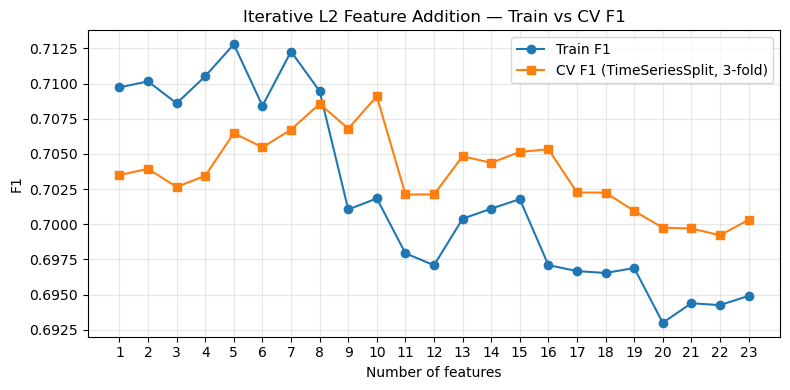

In [14]:
fig, ax = plt.subplots(figsize=(8,4))
ks = range(1, len(ordered_features)+1)
ax.plot(ks, train_f1s, 'o-', label='Train F1')
ax.plot(ks, cv_f1s,    's-', label='CV F1 (TimeSeriesSplit, 3-fold)')
ax.set_xlabel('Number of features'); ax.set_ylabel('F1'); ax.set_xticks(list(ks))
ax.set_title('Iterative L2 Feature Addition — Train vs CV F1')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Peak CV F1 defines k. Override manually after inspecting the elbow plot if needed.
# k_best = int(np.argmax(cv_f1s)) + 1
k_best = 8
selected_features = ordered_features[:k_best]
# print(f"k={k_best}  peak CV F1={cv_f1s[k_best-1]:.4f}  features: {selected_features}")

gs_final = GridSearchCV(LogisticRegression(max_iter=2000), param_grid=grid_l2, cv=tscv, scoring=f1_scorer, n_jobs=1)
gs_final.fit(X_rdy[selected_features], y)

model_freq = LogisticRegression(C=gs_final.best_params_['C'], penalty='l2',solver=gs_final.best_params_['solver'], max_iter=2000)
model_freq.fit(X_rdy[selected_features], y)

print(f"Final model — {gs_final.best_params_}")
print(f"Train F1: {f1_score(y, model_freq.predict(X_rdy[selected_features])):.4f}  "
      f"CV F1: {gs_final.best_score_:.4f}")

Final model — {'C': 0.001, 'penalty': 'l2', 'solver': 'newton-cg'}
Train F1: 0.7095  CV F1: 0.7086


### Decision Threshold Tuning - Recovering League-Wide Home Field Advantage

Calling the fitted logistic regression model on the data produces `predict_proba`, a continuous probability for each game. The **default threshold τ = 0.50** for classification algorithms implicitly assumes that home and away wins are equally likely a priori. In this case they are not. NFL home teams historically win approximately **57% of regular-season games** (which also implies class imbalance) so applying τ = 0.50 over-predicts home wins. You can see this from the imbalance between precision and recall in the confusion matrix when τ = 0.50.

> Models with class-imbalance can be trained with the addition of a class-weight hyperparameter which penalizes the loss function during training using the class-weight values, typically causing a minority-class error to count much more in the gradient update. This changes what the model learns. In contrast, threshold tuning doesen't touch training at all, it only changes how one interprets what the model learned. In the NFL case, class imballance is not severe enough to impede learning and the class mismatch is instead the result of the assumed decision threshold (50%) being incorrect. Here we demonstrate a use case of decision threshold tuning. 

By sweeping τ from 0.30 to 0.75 and finding the value where **precision equals recall**, we empirically recover the league-wide home field advantage. This should not be seen as a tuning trick, instead, it is a measurement.

**This threshold is the frequentist model's encoding of home field advantage: a single global number for the entire league.**

The Bayesian hierarchical model in Section 6 resolves this into something richer. Rather than one global intercept shared by all 32 teams, it estimates **`B_j0[j]`**, a separate home venue strength for each team **`j`**. A stadium known for crowd noise or altitude may sit at the top of the forest plot while a neutral or expansion venue may sit near the bottom. The `B_j0` posteriors are the probabilistic, team-specific version of the single threshold found here.

> *The frequentist threshold tells you the league average. The Bayesian posterior tells you the distribution across teams.*

Empirical home win rate : 0.553
Default  τ = 0.500 : Precision=0.609  Recall=0.849
Optimal  τ = 0.559 : Precision=0.659  Recall=0.657


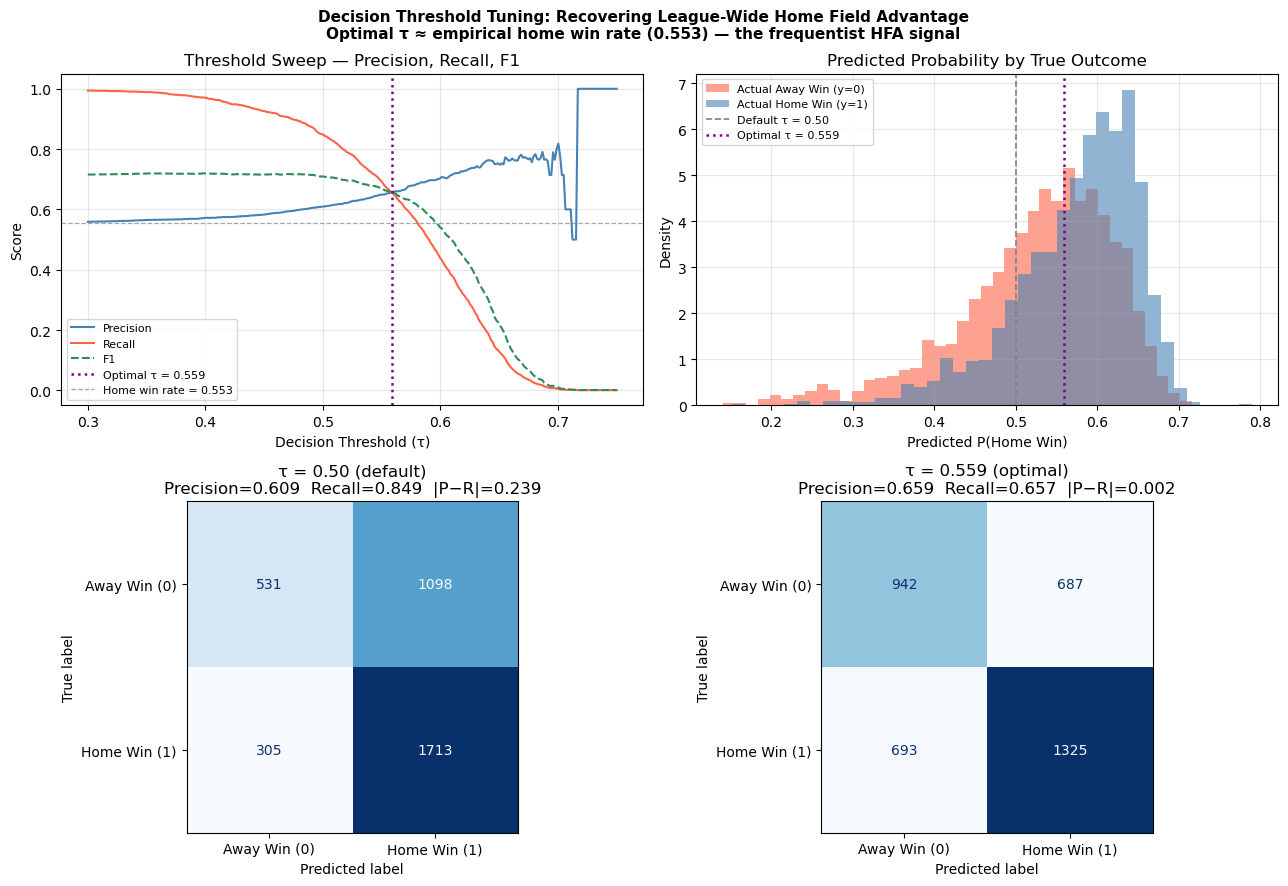

In [ ]:
# Decision Boundary Tuning

# Threshold sweep
thresholds = np.linspace(0.30, 0.75, 300)
proba_freq = model_freq.predict_proba(X_rdy[selected_features])[:, 1]
prec_vals  = [precision_score(y, (proba_freq >= t).astype(int), zero_division=0) for t in thresholds]
rec_vals   = [recall_score(y,    (proba_freq >= t).astype(int), zero_division=0) for t in thresholds]
f1_vals    = [f1_score(y,        (proba_freq >= t).astype(int), zero_division=0) for t in thresholds]

# Optimal threshold: where |precision - recall| is minimized
diffs = np.abs(np.array(prec_vals) - np.array(rec_vals))
opt_idx = int(np.argmin(diffs[np.nonzero(diffs)]))
opt_threshold = float(thresholds[opt_idx])

y_def = (proba_freq >= 0.50).astype(int)
y_opt = (proba_freq >= opt_threshold).astype(int)

print(f"Empirical home win rate : {y.mean():.3f}")
print(f"Default  τ = 0.500 : Precision={precision_score(y, y_def):.3f}  Recall={recall_score(y, y_def):.3f}")
print(f"Optimal  τ = {opt_threshold:.3f} : Precision={prec_vals[opt_idx]:.3f}  Recall={rec_vals[opt_idx]:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel 1 - Threshold sweep curves
ax = axes[0, 0]
ax.plot(thresholds, prec_vals, color='steelblue', label='Precision')
ax.plot(thresholds, rec_vals,  color='tomato',    label='Recall')
ax.plot(thresholds, f1_vals,   color='seagreen',  label='F1', linestyle='--')
ax.axvline(opt_threshold, color='purple', linestyle=':', linewidth=1.8, label=f'Optimal τ = {opt_threshold:.3f}')
ax.axhline(y.mean(), color='grey', linestyle='--', linewidth=0.9, alpha=0.7, label=f'Home win rate = {y.mean():.3f}')
ax.set_xlabel('Decision Threshold (τ)')
ax.set_ylabel('Score')
ax.set_title('Threshold Sweep — Precision, Recall, F1')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 2 - Predicted probability histogram by true outcome
ax = axes[0, 1]
ax.hist(proba_freq[y == 0], bins=40, density=True, alpha=0.6, color='tomato', label='Actual Away Win (y=0)')
ax.hist(proba_freq[y == 1], bins=40, density=True, alpha=0.6, color='steelblue', label='Actual Home Win (y=1)')
ax.axvline(0.50,          color='grey',   linestyle='--', linewidth=1.2, label='Default τ = 0.50')
ax.axvline(opt_threshold, color='purple', linestyle=':',  linewidth=1.8, label=f'Optimal τ = {opt_threshold:.3f}')
ax.set_xlabel('Predicted P(Home Win)')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability by True Outcome')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 3 - Confusion matrix at τ = 0.50
ax = axes[1, 0]
p0 = precision_score(y, y_def); r0 = recall_score(y, y_def)
ConfusionMatrixDisplay(confusion_matrix(y, y_def),
                       display_labels=['Away Win (0)', 'Home Win (1)']
                       ).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'τ = 0.50 (default)\nPrecision={p0:.3f}  Recall={r0:.3f}  |P−R|={abs(p0-r0):.3f}')

# Panel 4 - Confusion matrix at optimal τ
ax = axes[1, 1]
po = precision_score(y, y_opt); ro = recall_score(y, y_opt)
ConfusionMatrixDisplay(confusion_matrix(y, y_opt),
                       display_labels=['Away Win (0)', 'Home Win (1)']
                       ).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'τ = {opt_threshold:.3f} (optimal)\nPrecision={po:.3f}  Recall={ro:.3f}  |P−R|={abs(po-ro):.3f}')

fig.suptitle('Decision Threshold Tuning: Recovering League-Wide Home Field Advantage\n'
             f'Optimal τ ≈ empirical home win rate ({y.mean():.3f}) — the frequentist HFA signal',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 5 - Frequentist Simulation

`model_freq` produces a **fixed win probability** for every game. These probabilities do not vary across draws. They are point estimates with no uncertainty. Each draw simply flips 272 biased coins using those fixed probabilities and tallies wins.

**Expected result:** The simulated win distribution will be too narrow (over-concentrated around 8 wins) because fixed probabilities remove all season-level team variance. This motivates the Bayesian model in Section 6.

In [17]:
valid_seasons = sorted(df['season'].unique())
hist_stats = season_stats[season_stats['season'].isin(valid_seasons)]

# historical win distribution
hist_win_counts = hist_stats['actual_wins'].values
print(f"Historical: {len(hist_win_counts)} team-season obs  "
      f"wins {hist_win_counts.min():.0f}–{hist_win_counts.max():.0f}  "
      f"mean={hist_win_counts.mean():.2f}  std={hist_win_counts.std():.2f}")

Historical: 448 team-season obs  wins 0–15  mean=8.14  std=3.11


In [18]:
# Run Monte Carlo Simulation of NFL seasons using the frequentist model's win probabilities

N_DRAWS = 500  # number of simulated seasons
freq_win_counts = []

for season in valid_seasons:  
    mask       = df['season'] == season  # filters to one season's games 
    ht_names_s = df.loc[mask,'home_team'].values
    at_names_s = df.loc[mask,'away_team'].values
    teams_s    = np.unique(np.concatenate([ht_names_s, at_names_s]))
    probs      = model_freq.predict_proba(X_rdy.loc[mask, selected_features])[:,1]  # runs season's games through the model, returns hom-win probability for each game, [:,1] selects the positive class column

    # for each game in the selected season, draw a uniform random nmber and compare it to the model's probability
    for _ in range(N_DRAWS): 
        home_won = np.random.rand(len(probs)) < probs
        wins = dict.fromkeys(teams_s, 0)  # initializes every team's wincount to 0
        for i, (ht, at) in enumerate(zip(ht_names_s, at_names_s)):  # walk through all games and credit the winner
            wins[ht if home_won[i] else at] += 1
        freq_win_counts.extend(wins.values())  # append all 32 team's win totals from this one simulated season into the flat list. 

print(f"Frequentist simulation: {len(freq_win_counts):,} team-season win totals")

Frequentist simulation: 224,000 team-season win totals


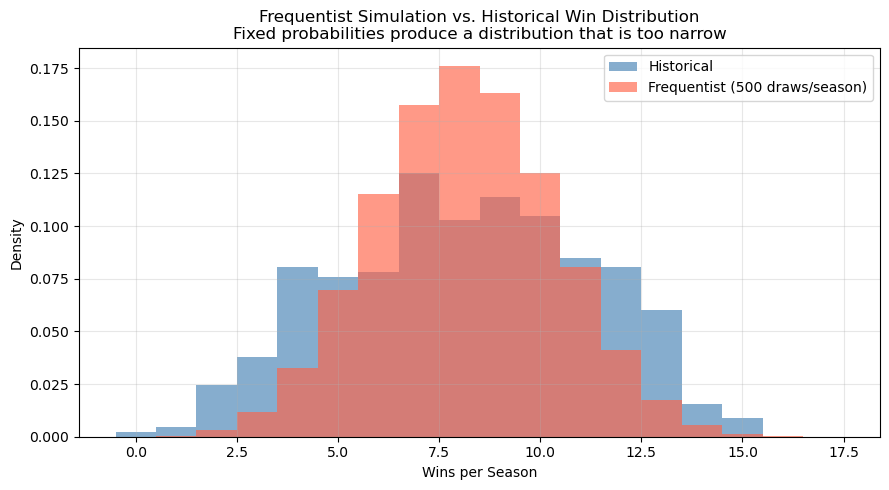

In [19]:
# Plot the historical vs simulated win distrubutions

bins = np.arange(-0.5, 18.5)
fig, ax = plt.subplots(figsize=(9,5))

# historical distribution
ax.hist(hist_win_counts, bins=bins, density=True, alpha=0.65, color='steelblue', label='Historical')

# simulated (frequentist) distribution
ax.hist(freq_win_counts, bins=bins, density=True, alpha=0.65, color='tomato', label=f'Frequentist ({N_DRAWS} draws/season)')

ax.set_xlabel('Wins per Season'); ax.set_ylabel('Density')
ax.set_title('Frequentist Simulation vs. Historical Win Distribution\n'
             'Fixed probabilities produce a distribution that is too narrow')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Observation:** The frequentist histogram is too narrow (over-concentrated near 8 wins). 
When outcomes are truly independent game-by-game, win totals cluster more heavily around the mean, but in reality, outcomes are not independent, but correlated based on team-level momentum within seasons. This correlation inflates the variance of win totals. The historical distribution is evidence of this with a noticeably flatter distribution, with more probability mass at extreme win totals. The frequentist simulation misses this because it treats each game as a fresh draw with no memory of the season-level effect. 

The missing ingredient is correlated within-season team performance: a team's season-level deviation from expectation is not zero, and it typically persists across all 16 games. A Bayesian hierarchical model captures this as a latent per-team-season random effect.

## Section 6 - Bayesian Hierarchical Model

### Model Structure

**Home venue effect `B_j0[j]`** - one coefficient per home team. Captures structural home-field advantage (crowd, altitude, familiarity). Non-centered parameterization improves sampler efficiency.

**Feature coefficients `B_features`** - one coefficient per selected feature (names resolved from Section 4).

**Year-team random effect `e_tk[t,k]`** - one latent value per (team × season) pair, indexed over all team-season appearances (home *and* away). The formulation uses `e_tk[yr_ht] − e_tk[yr_at]` in the likelihood, so both team roles contribute to `σ` estimation.

$$W_{ijk} = B_{j0}[\text{ht}] + \mathbf{B}_{\text{feat}} \cdot \mathbf{x} + e_{tk}[\text{yr\_ht}] - e_{tk}[\text{yr\_at}]$$
$$P(\text{home wins}) = \sigma(W_{ijk})$$

The model is fit on **all available data**. The goal is a well-calibrated `σ_e_tk` for simulation, not a held-out prediction benchmark.

In [20]:
selected_features

['diff_wintotals',
 'at_superbowl_odds ht_wintotal_vs_pyth_lag',
 'ht_playoff_miss_odds at_wintotal_vs_pyth_lag',
 'diff_longitudes ht_pyth_overperf_lag',
 'at_conference_prob diff_pyth_wins_lag',
 'ht_playoff_miss_prob ht_division_prob',
 'at_conference_prob diff_superbowl_prob',
 'ht_playoff_miss_odds ht_wintotal_vs_pyth_lag']

# Build Hierarchical coordinate system
### The following code sets up integer index arrays that PyMC uses to look up the right latent variable for each game

In [ ]:
# Home team indices for B_j0
home_idx, home_teams = pd.factorize(df['home_team'], sort=True)

# Year-team indices for e_tk — joint factorization over ALL team-season appearances
df['yr_ht'] = df['season'].astype(str) + '_' + df['home_team']  # ie: 2021_KC or '2019_NE'  (the latent variable e_tk is indexed by both team and year)
df['yr_at'] = df['season'].astype(str) + '_' + df['away_team']
all_yr_teams  = np.concatenate([df['yr_ht'].values, df['yr_at'].values])
yr_teams, inv = np.unique(all_yr_teams, return_inverse=True)  # numpy equivalent of pd.factorize, guarentees that '2021_KC' gets the same integer everywhere it appears regardless of home or away
yr_ht_idx = inv[:len(df)]  # integer codes for game i's home team-season latent effects
yr_at_idx = inv[len(df):]  # integer codes for game i's away team-season latent effects

# in PyMC when we write something like etk[yr_ht_idx], PyMC treats it as a gather operation: for each game, pull the latent random effect for that 
# team-season out of the fector of all team-season effects. These index arrays are the lookup table that makes this possible.

# Scale selected features for the Bayesian model
scaler_bayes = StandardScaler().fit(X_poly_raw[selected_features]) 
X_bayes = scaler_bayes.transform(X_poly_raw[selected_features])  # scaled data viewing only selected features
y_obs = df['home_team_won'].values.astype(int)  # target

# Bayesian model coordinates
coords = {
    'game_idx':   df.index.tolist(),
    'home_teams': home_teams.tolist(),
    'yr_teams':   yr_teams.tolist()
}
print(f"Games: {len(df)}  |  Home teams: {len(home_teams)}  |  Year-team pairs: {len(yr_teams)}")
print(f"Bayesian model features: {selected_features}")

Games: 3647  |  Home teams: 32  |  Year-team pairs: 448
Bayesian model features: ['diff_wintotals', 'at_superbowl_odds ht_wintotal_vs_pyth_lag', 'ht_playoff_miss_odds at_wintotal_vs_pyth_lag', 'diff_longitudes ht_pyth_overperf_lag', 'at_conference_prob diff_pyth_wins_lag', 'ht_playoff_miss_prob ht_division_prob', 'at_conference_prob diff_superbowl_prob', 'ht_playoff_miss_odds ht_wintotal_vs_pyth_lag']


In [ ]:
# Define the Bayesian model, parameters, and Likelihood
with pm.Model(coords=coords) as hierarchical_model:

    # Home venue strength - non-centered parameterization
    # mu_B0 = pm.Normal('mu_B0', mu=0, sigma=1)
    # sigma_B0 = pm.HalfNormal('sigma_B0', sigma=1)
    # B0_offset = pm.Normal('B0_offset', mu=0, sigma=1, dims='home_teams')
    # B_j0 = pm.Deterministic('B_j0', mu_B0 + sigma_B0 * B0_offset, dims='home_teams')
    B_j0 = pm.Normal("B_j0", 0.2888, 0.1352, dims="home_teams")  # domain knowledge of home advantage prior

    # Feature coefficients (names are TBD from feature selection output)
    B_features = pm.Normal('B_features', mu=0, sigma=.7, shape=len(selected_features))

    # Year-team random effects - non-centered; σ_e_tk is the key simulation parameter
    sigma_e_tk = pm.HalfNormal('sigma_e_tk', sigma=1)
    e_tk_offset = pm.Normal('e_tk_offset', mu=0, sigma=1, dims='yr_teams')
    e_tk = pm.Deterministic('e_tk', sigma_e_tk * e_tk_offset, dims='yr_teams')

    # Linear predictor
    mu = (
        B_j0[home_idx]
        + pm.math.dot(X_bayes, B_features)
        + e_tk[yr_ht_idx] - e_tk[yr_at_idx]
    )

    # Likelihood
    p  = pm.Deterministic('p', pm.math.sigmoid(mu), dims='game_idx')
    obs = pm.Bernoulli('obs', p=p, observed=y_obs, dims='game_idx')

In [23]:
# sample prior predictive for sanity check
with hierarchical_model:
    prior_trace = pm.sample_prior_predictive(1000)

c:\Users\ASR10\anaconda3\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sampling: [B_features, B_j0, e_tk_offset, obs, sigma_e_tk]


<Axes: xlabel='obs'>

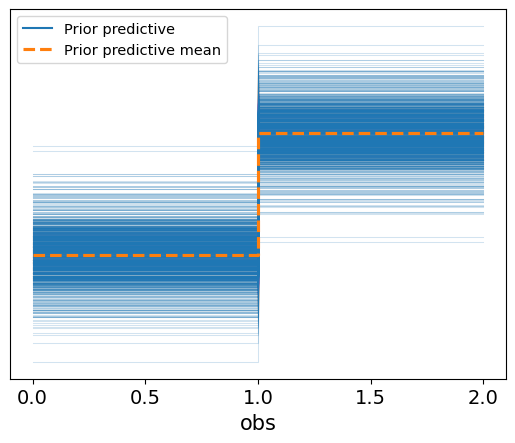

In [24]:
# Sanity check
az.plot_ppc(prior_trace, group = "prior")

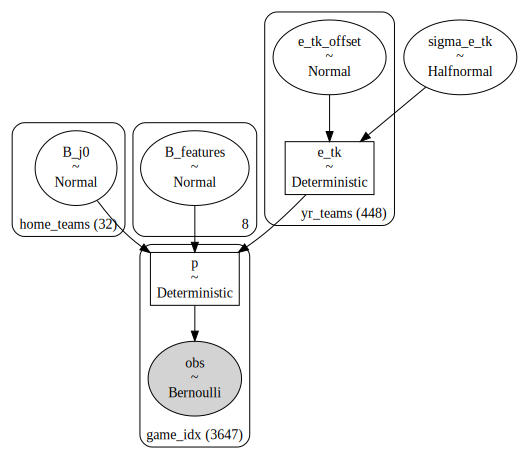

In [25]:
# view model diagram  (showing non-centered parameterization for e_tk)
pm.model_to_graphviz(hierarchical_model)

In [26]:
# Sample the model
with hierarchical_model:
    trace = pm.sample(
        draws=5000, tune=2000, chains=4,
        target_accept=0.9, random_seed=42,
        return_inferencedata=True
    )

trace.to_netcdf('NFLmodel_Hierarchical_v2.nc')
print("Sampling complete. Trace saved to NFLmodel_Hierarchical_v2.nc")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [B_j0, B_features, sigma_e_tk, e_tk_offset]


Output()

Sampling 4 chains for 2_000 tune and 5_000 draw iterations (8_000 + 20_000 draws total) took 212 seconds.


Sampling complete. Trace saved to NFLmodel_Hierarchical_v2.nc


## Section 7 - Model Results

In [27]:
# Reload from file if kernel was restarted after sampling:
# trace = az.from_netcdf('NFLmodel_Hierarchical_v2.nc')

# summary = az.summary(trace, var_names=['mu_B0','sigma_B0','sigma_e_tk','B_features'], round_to=4)
summary = az.summary(trace, var_names=['B_j0', 'sigma_e_tk','B_features'], round_to=4)
print("Convergence: R-hat target < 1.01  |  ESS target > 400")
display(summary)

Convergence: R-hat target < 1.01  |  ESS target > 400


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
B_j0[ARI],0.2954,0.1194,0.0673,0.5146,0.0008,0.0008,23137.9310,15415.2006,1.0001
B_j0[ATL],0.2219,0.1186,0.0013,0.4450,0.0007,0.0009,29279.5405,15067.3918,1.0000
B_j0[BAL],0.3757,0.1186,0.1501,0.5957,0.0008,0.0009,23656.0157,15356.1651,1.0003
B_j0[BUF],0.3980,0.1184,0.1678,0.6161,0.0008,0.0008,23141.8945,15822.6601,1.0001
B_j0[CAR],0.2628,0.1179,0.0428,0.4855,0.0008,0.0009,22910.1895,14585.8690,1.0000
B_j0[CHI],0.2300,0.1177,0.0110,0.4488,0.0008,0.0008,21861.8230,14783.8315,1.0001
B_j0[CIN],0.2842,0.1189,0.0602,0.5074,0.0008,0.0009,21306.7703,13331.5692,1.0002
B_j0[CLE],0.2986,0.1200,0.0692,0.5212,0.0008,0.0009,25409.3336,14658.3126,1.0000
B_j0[DAL],0.2439,0.1204,0.0160,0.4678,0.0008,0.0009,23918.3271,14308.5095,1.0003
B_j0[DEN],0.3376,0.1188,0.1108,0.5570,0.0008,0.0008,22259.3167,15192.1387,1.0003


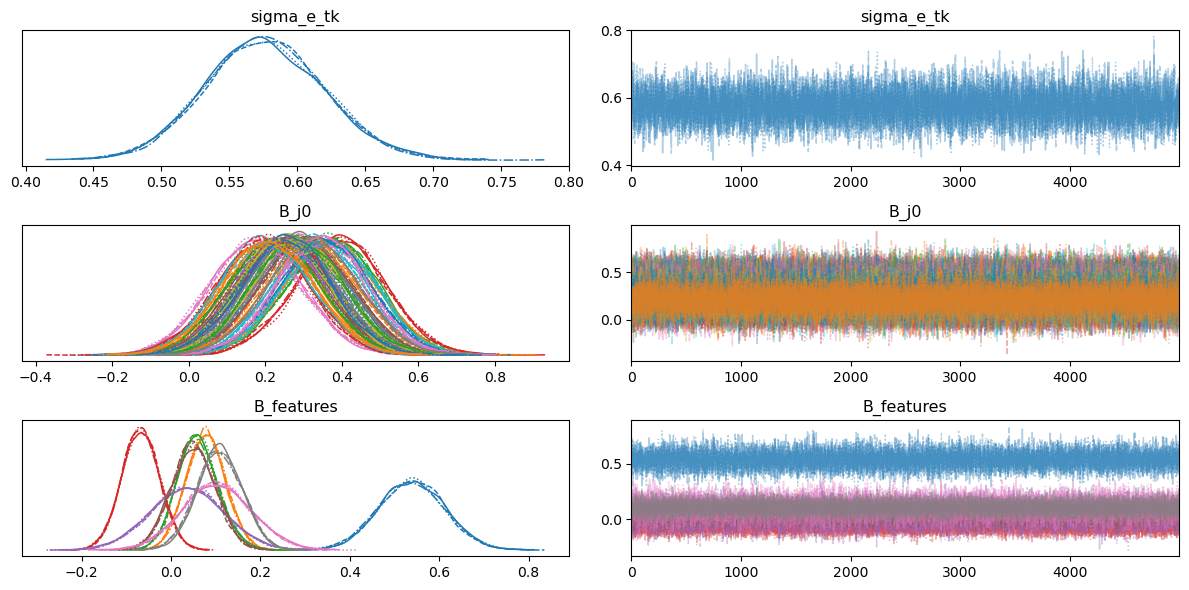

In [28]:
az.plot_trace(trace, var_names=['sigma_e_tk','B_j0','B_features'], compact=True)
plt.tight_layout(); plt.show()

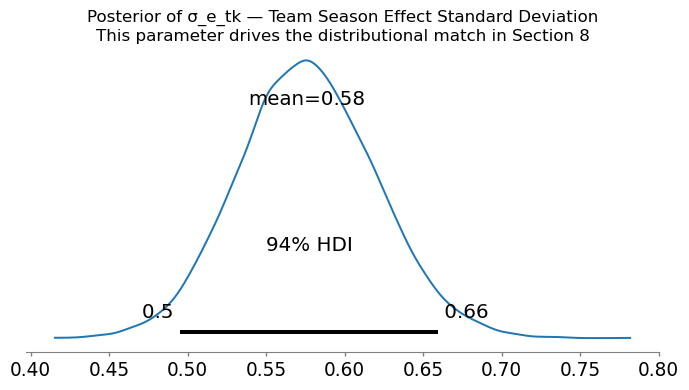

In [29]:
# Now plot the posterior of σ_e_tk. This is the distribution we will draw from for the Bayesian season simulator
az.plot_posterior(trace, var_names=['sigma_e_tk'], hdi_prob=0.94, figsize=(7,4))
plt.gca().set_title(
    'Posterior of σ_e_tk — Team Season Effect Standard Deviation\n'
    'This parameter drives the distributional match in Section 8'
)
plt.tight_layout(); plt.show()

## Home field advantage per team

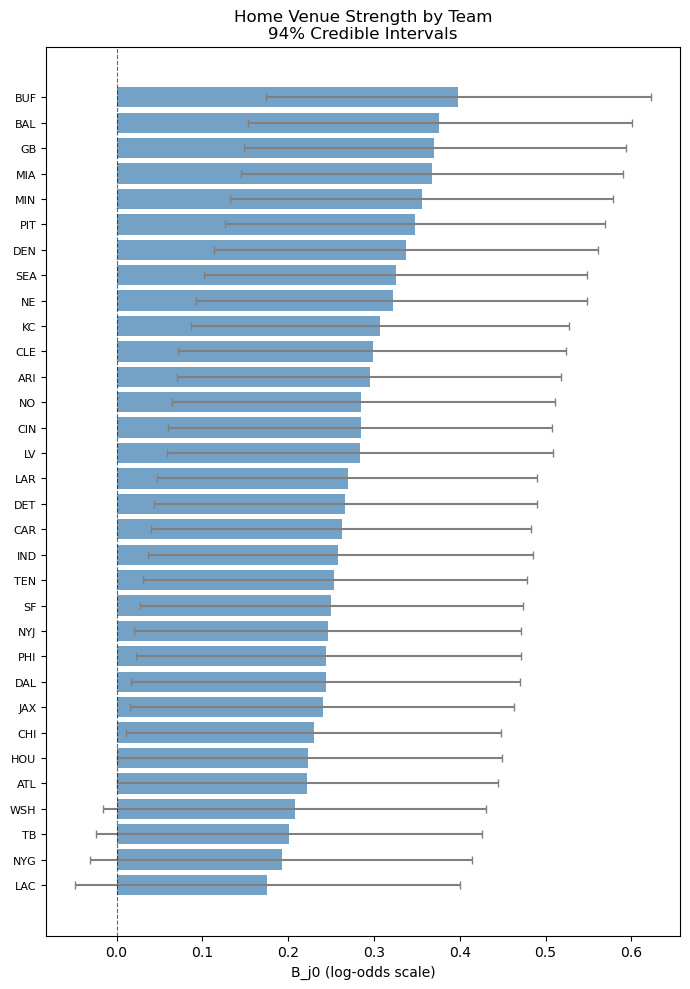

In [30]:
# B_j0 forest plot - home venue strength per team, sorted by posterior mean
b_j0_flat  = trace.posterior['B_j0'].values.reshape(-1, len(home_teams))
b_j0_means = b_j0_flat.mean(axis=0)
b_j0_lo    = np.percentile(b_j0_flat, 3.0,  axis=0)
b_j0_hi    = np.percentile(b_j0_flat, 97.0, axis=0)
order      = np.argsort(b_j0_means)

fig, ax = plt.subplots(figsize=(7, 10))
y_pos = np.arange(len(home_teams))
ax.barh(y_pos, b_j0_means[order],
        xerr=[b_j0_means[order]-b_j0_lo[order], b_j0_hi[order]-b_j0_means[order]],
        alpha=0.75, capsize=3, color='steelblue', ecolor='grey')
ax.set_yticks(y_pos)
ax.set_yticklabels([home_teams[i] for i in order], fontsize=8)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('B_j0 (log-odds scale)')
ax.set_title('Home Venue Strength by Team\n94% Credible Intervals')
plt.tight_layout(); plt.show()

## Section 8 - Bayesian Season Simulation

The Bayesian simulation adds one step before each season draw: **sample `σ` from the posterior of `σ_e_tk`, then draw one season-level random effect per team from `Normal(0, σ)`**. That effect is applied to every game the team plays that season, creating correlated outcomes across the schedule.

Fixed effects (`B_j0`, `B_features`) use posterior means. Propagating uncertainty through `σ_e_tk` alone is sufficient to produce the distributional match. Coefficient uncertainty is secondary. This choice is discussed in the methodology section.

**Expected result:** The win distribution matches the historical plateau shape.

In [ ]:
sigma_post      = trace.posterior['sigma_e_tk'].values.flatten()
B_feat_flat     = trace.posterior['B_features'].values.reshape(-1, len(selected_features))
B_j0_flat_sim   = trace.posterior['B_j0'].values.reshape(-1, len(home_teams))

B_features_means = B_feat_flat.mean(axis=0)
B_j0_means_sim = B_j0_flat_sim.mean(axis=0)
scaler_means_b = scaler_bayes.mean_
scaler_scales_b = scaler_bayes.scale_
ht_name_to_idx = {t: i for i, t in enumerate(home_teams)}

print(f"σ_e_tk  mean={sigma_post.mean():.3f}  std={sigma_post.std():.3f}")
print(f"B_features means: {dict(zip(selected_features, B_features_means.round(4)))}")

σ_e_tk  mean=0.576  std=0.044
B_features means: {'diff_wintotals': 0.5384, 'at_superbowl_odds ht_wintotal_vs_pyth_lag': 0.0776, 'ht_playoff_miss_odds at_wintotal_vs_pyth_lag': 0.0592, 'diff_longitudes ht_pyth_overperf_lag': -0.068, 'at_conference_prob diff_pyth_wins_lag': 0.0359, 'ht_playoff_miss_prob ht_division_prob': 0.0496, 'at_conference_prob diff_superbowl_prob': 0.1026, 'ht_playoff_miss_odds ht_wintotal_vs_pyth_lag': 0.1081}


In [ ]:
# Same Monte-Carlo structure as the frequentist loop, but now each simulated season draws latent parameters from the posterior before simulating games

bayes_win_counts = []

for season in valid_seasons:  # for each season
    mask = df['season'] == season  # filter to one season
    s_df = df[mask]
    s_poly = X_poly_raw[mask]
    ht_names_s = s_df['home_team'].values
    at_names_s = s_df['away_team'].values
    teams_s = np.unique(np.concatenate([ht_names_s, at_names_s]))
    X_s_scaled = (s_poly[selected_features].values - scaler_means_b) / scaler_scales_b  # scales the feature matrix manually using the stored posterior means of the scaler so the scaling is consistent with training
    ht_idxs = np.array([ht_name_to_idx.get(t, 0) for t in ht_names_s])

    for _ in range(N_DRAWS):
        sigma_k = sigma_post[np.random.randint(len(sigma_post))]  # randomly picks one posterior draw of sigma_k - the standard deviation of the team-season random effect - this propagates posterior uncertainty into the simulation
        team_effects = dict(zip(teams_s, np.random.normal(0, sigma_k, len(teams_s))))  # draws one latent season-level quality offset for every team, centered at 0 with spread sigma_k. this creates the winin-season correlation that widens the win-total distribution

        # expand the team-level draws into game-level arrays
        ht_eff = np.array([team_effects[t] for t in ht_names_s])
        at_eff = np.array([team_effects[t] for t in at_names_s])

        # compute the linear predictor (team-specific home intercept + numerical feature contribution + home team's latent season qualityh draw - away team's latent season quality draw)
        W = B_j0_means_sim[ht_idxs] + X_s_scaled @ B_features_means + ht_eff - at_eff  # W is logg-odds (positive means home team favored)

        home_won = np.random.rand(len(W)) < expit(W)  # expit is the imported sigmoid function, converts log-odds to probability
        wins = dict.fromkeys(teams_s, 0)
        for i, (ht, at) in enumerate(zip(ht_names_s, at_names_s)):
            wins[ht if home_won[i] else at] += 1  # Bernoulli draw
        bayes_win_counts.extend(wins.values())

print(f"Bayesian simulation: {len(bayes_win_counts):,} team-season win totals")

Bayesian simulation: 224,000 team-season win totals


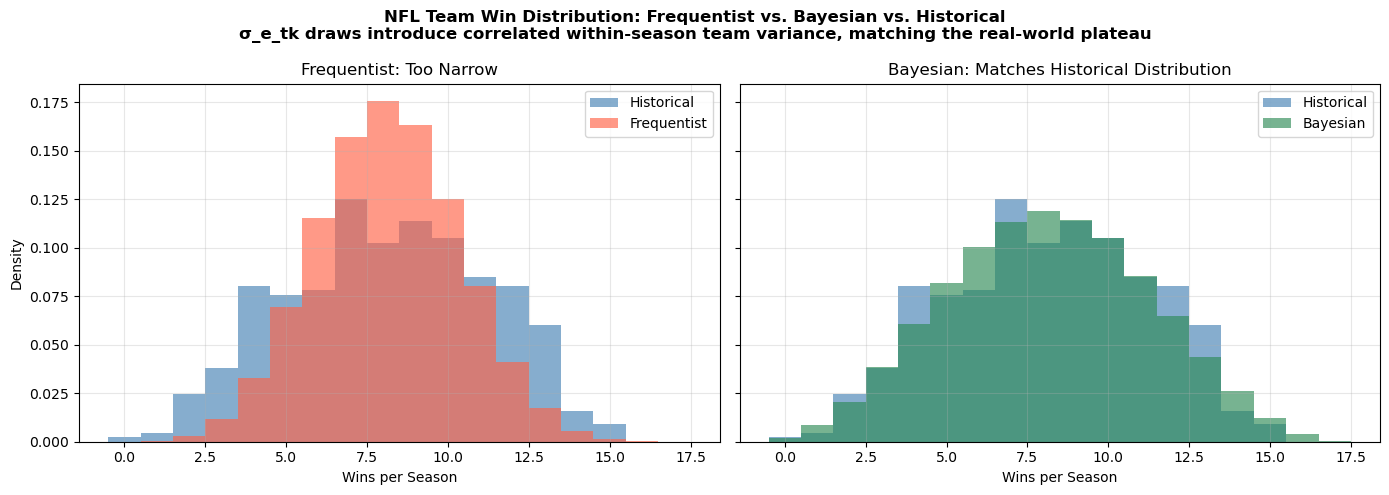

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
bins = np.arange(-0.5, 18.5)

ax = axes[0]
ax.hist(hist_win_counts, bins=bins, density=True, alpha=0.65, color='steelblue', label='Historical')
ax.hist(freq_win_counts, bins=bins, density=True, alpha=0.65, color='tomato',    label='Frequentist')
ax.set_xlabel('Wins per Season'); ax.set_ylabel('Density')
ax.set_title('Frequentist: Too Narrow')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(hist_win_counts,  bins=bins, density=True, alpha=0.65, color='steelblue', label='Historical')
ax.hist(bayes_win_counts, bins=bins, density=True, alpha=0.65, color='seagreen',  label='Bayesian')
ax.set_xlabel('Wins per Season')
ax.set_title('Bayesian: Matches Historical Distribution')
ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle(
    'NFL Team Win Distribution: Frequentist vs. Bayesian vs. Historical\n'
    'σ_e_tk draws introduce correlated within-season team variance, matching the real-world plateau',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(); plt.show()

## Section 9 - Single-Season U-Matrix

We simulate the 2021 season in the dataset 100 times using our newly calibrated Bayesian model. Each column of the U-matrix is one complete season: a `σ` draw from the posterior, one random effect per team, then binary outcomes for all 272 regular-season matchups.

Convention (consistent with prior notebooks): `0` = home team won, `1` = away team won.

The U-matrix is the deliverable for downstream optimization or game-theory workflows - each column is one plausible realization of the season. In our case, we will use the U-matrix as an input to a proprietary 2-stage stochastic MILP to generate an optimized NFL playing schedule

In [34]:
most_recent_season = 2021  # target 2021 
season_df = df[df['season'] == most_recent_season].reset_index(drop=False)
season_poly = X_poly_raw.loc[season_df['index']]

# 2021 has 272 games
assert len(season_df) == 272, (
    f"Expected 272 regular-season games for 2021, found {len(season_df)}."
)

matchup_labels = [f"{r['away_team']} @ {r['home_team']}" for _, r in season_df.iterrows()]
ht_names_s     = season_df['home_team'].values
at_names_s     = season_df['away_team'].values
teams_s        = np.unique(np.concatenate([ht_names_s, at_names_s]))
X_s_scaled     = (season_poly[selected_features].values - scaler_means_b) / scaler_scales_b
ht_idxs_s      = np.array([ht_name_to_idx.get(t, 0) for t in ht_names_s])

print(f"Season {most_recent_season}: {len(season_df)} games, {len(teams_s)} teams")

Season 2021: 272 games, 32 teams


In [35]:
N_DRAWS = 100
n_games = len(season_df)
U_prob   = np.empty((n_games, N_DRAWS))
U_result = np.empty((n_games, N_DRAWS), dtype=int)

for draw in range(N_DRAWS):
    sigma_k      = sigma_post[np.random.randint(len(sigma_post))]
    team_effects = dict(zip(teams_s, np.random.normal(0, sigma_k, len(teams_s))))
    ht_eff       = np.array([team_effects[t] for t in ht_names_s])
    at_eff       = np.array([team_effects[t] for t in at_names_s])
    W            = B_j0_means_sim[ht_idxs_s] + X_s_scaled @ B_features_means + ht_eff - at_eff
    probs        = expit(W)
    U_prob[:, draw]   = probs
    home_won          = (np.random.rand(n_games) < probs).astype(int)
    U_result[:, draw] = 1 - home_won  # 0=home won, 1=away won

print(f"U-matrix shape: {U_result.shape}  (matchups × draws)")

U-matrix shape: (272, 100)  (matchups × draws)


In [36]:
U_df = pd.DataFrame(U_result, index=matchup_labels,
                    columns=[f'draw_{i}' for i in range(N_DRAWS)])
display(U_df.iloc[:10, :8])

,draw_0,draw_1,draw_2,draw_3,draw_4,draw_5,draw_6,draw_7
DAL @ TB,0,0,1,0,0,1,0,0
CHI @ LAR,0,0,0,0,1,0,1,0
MIA @ NE,0,1,1,0,0,0,1,0
GB @ NO,1,0,0,1,0,1,0,1
DEN @ NYG,1,0,1,0,1,0,1,0
CLE @ KC,0,0,0,0,0,0,0,1
LAC @ WSH,1,0,1,0,0,1,1,0
JAX @ HOU,1,0,1,1,1,1,1,1
SF @ DET,1,0,1,1,0,1,1,1
ARI @ TEN,1,1,0,1,1,1,1,1


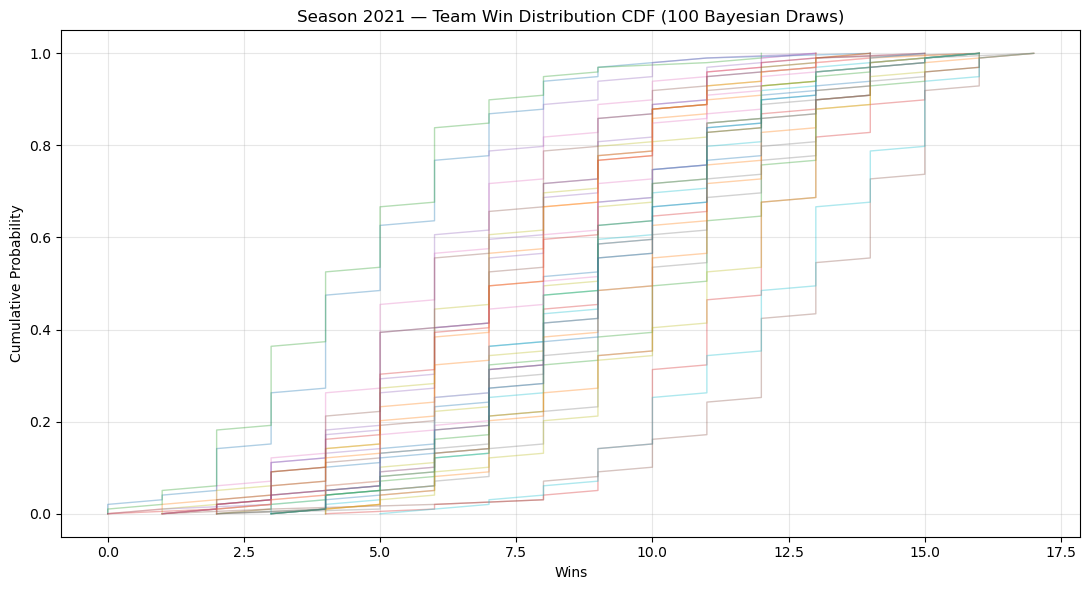

In [37]:
# Team win CDF - full distribution of plausible season outcomes per team
team_wins = np.zeros((len(teams_s), N_DRAWS), dtype=int)
for draw in range(N_DRAWS):
    wins = dict.fromkeys(teams_s, 0)
    for i, (ht, at) in enumerate(zip(ht_names_s, at_names_s)):
        wins[ht if U_result[i, draw] == 0 else at] += 1
    for j, team in enumerate(teams_s):
        team_wins[j, draw] = wins[team]

fig, ax = plt.subplots(figsize=(11, 6))
for j in range(len(teams_s)):
    ax.plot(np.sort(team_wins[j]), np.linspace(0, 1, N_DRAWS), alpha=0.35, linewidth=1)
ax.set_xlabel('Wins'); ax.set_ylabel('Cumulative Probability')
ax.set_title(f'Season {most_recent_season} — Team Win Distribution CDF ({N_DRAWS} Bayesian Draws)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [38]:
np.savetxt(f'U_{most_recent_season}.csv', U_result, delimiter=',')
np.savetxt(f'matchup_labels_{most_recent_season}.txt', np.array(matchup_labels, dtype=object), fmt='%s')
print(f"U-matrix saved to U_{most_recent_season}.csv")
print(f"Matchup labels saved to matchup_labels_{most_recent_season}.txt")

U-matrix saved to U_2021.csv
Matchup labels saved to matchup_labels_2021.txt
